In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mplfinance as mpf #Usado para explorar os dados (instancia de finanças do matplot)
import yfinance as yf #Usado para comparar com nossos dados (basicamente nos deixa baixar dados oficiais da bolsa de valores)

In [30]:
path = "..\data\S&P 500 Stock Prices 2014-2017.csv"
df = pd.read_csv(path, sep=",")
display(df.head(10))

<>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\Taylb\AppData\Local\Temp\ipykernel_10872\441904907.py:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  path = "..\data\S&P 500 Stock Prices 2014-2017.csv"


,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391
5,ABT,2014-01-02,38.0900,38.4000,38.0000,38.2300,4967472
6,ACN,2014-01-02,81.5000,81.9200,81.0900,81.1300,2405384
7,ADBE,2014-01-02,59.0600,59.5300,58.9400,59.2900,2746370
8,ADI,2014-01-02,49.5200,49.7500,49.0400,49.2800,2799092
9,ADM,2014-01-02,43.2200,43.2900,42.7900,42.9900,2753765


In [31]:
df.info()
df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 497472 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   symbol  497472 non-null  str    
 1   date    497472 non-null  str    
 2   open    497461 non-null  float64
 3   high    497464 non-null  float64
 4   low     497464 non-null  float64
 5   close   497472 non-null  float64
 6   volume  497472 non-null  int64  
dtypes: float64(4), int64(1), str(2)
memory usage: 32.8 MB


symbol     0
date       0
open      11
high       8
low        8
close      0
volume     0
dtype: int64

In [32]:
df["date"] = pd.to_datetime(df["date"])

Nulos a serem tratados no "open", "high" e "low", entretanto, essas colunas não aceitam valores nulos... teremos que analisar como tratar isso.

[*********************100%***********************]  1 of 1 completed
c:\Users\Taylb\AppData\Local\Programs\Python\Python314\Lib\site-packages\mplfinance\_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


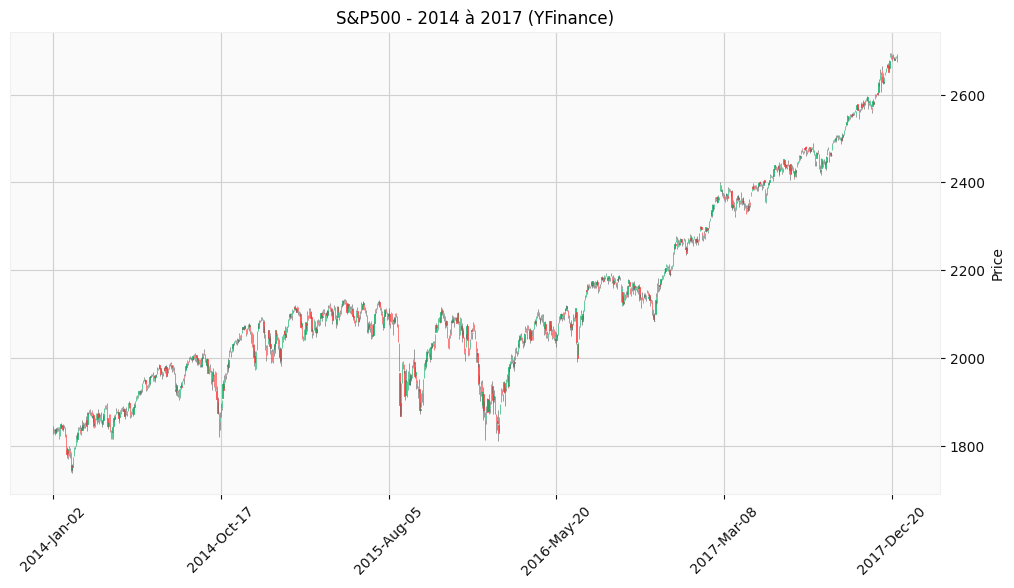

In [33]:
#Modelo de referencia do S&P500

df_teste = yf.download("^GSPC", multi_level_index=False, start='2014-01-01', end='2017-12-30')

fig, ax = plt.subplots(figsize=(12,6))
mpf.plot(df_teste, type="candle", style="yahoo", ax=ax)
ax.set_title("S&P500 - 2014 à 2017 (YFinance)")
plt.show()

Os dados do dataset original, não possuem dados o suficiente para recriar o índice S&P500, por essa razão, vamos limitar a analise por empresa...

Empresas selecionadas:
RTX
LMT
BA
GD
AVAV

In [34]:
#ALgoritmo para verificar se as empresas estão no dataset e se os dados estão completos
from IPython.display import clear_output
Empresas = ["RTX", "LMT", "BA", "GD", "AVAV"]

for e in Empresas:
    aux = df[df["symbol"] == e]
    print("=" * 10)
    print(f"Empresa: {e}")
    print("INFO:")
    print(aux.info())
    print("=" * 10)
    input("Pressione ENTER para continuar")
    clear_output()
    

Empresas que passaram pela validação:
LMT
BA
GD

Agora, precisamos comparar os dados do yfinance com dataset

In [39]:
Empresas = ["LMT", "BA", "GD"]

for e in Empresas:
    aux = df[df["symbol"] == e]
    aux = aux.set_index('date')
    df_teste = yf.download(e, multi_level_index=False, start='2014-01-01', end='2017-12-30')

    fig, ax = plt.subplots(figsize=(12,6), ncols=2, nrows=1)
    mpf.plot(df_teste, type="candle", style="yahoo", ax=ax[0])
    ax[0].set_title(f"{e} - 2014 à 2017 (YFinance)")
    
    mpf.plot(aux, type="candle", style="yahoo", ax=ax[1])
    ax[1].set_title(f"{e} - 2014 à 2017 (DataSet)")
    plt.show()
    input("Pressione ENTER para continuar")
    clear_output()

In [43]:
for e in Empresas:
    aux = df[df["symbol"] == e]
    aux.set_index("date", inplace=True)
    aux.sort_index(ascending=True, inplace=True)
    print(aux)
    aux.to_csv("../data/tratados/" + e + ".csv", index=True)

           symbol    open      high       low   close   volume
date                                                          
2014-01-02    LMT  147.05  147.7900  145.8400  146.07  1115858
2014-01-03    LMT  146.50  147.3300  146.4750  147.06   843422
2014-01-06    LMT  147.30  148.0899  146.1000  146.28  1134990
2014-01-07    LMT  149.00  149.3000  147.5000  148.61  1684141
2014-01-08    LMT  148.39  149.1040  147.7101  148.50  1222706
...           ...     ...       ...       ...     ...      ...
2017-12-22    LMT  317.99  319.2400  317.6000  318.03   542941
2017-12-26    LMT  318.36  319.7700  317.9700  318.51   517446
2017-12-27    LMT  319.67  319.6700  318.0701  319.44   574679
2017-12-28    LMT  319.83  322.3000  319.7100  322.10   721724
2017-12-29    LMT  322.22  323.1500  321.0200  321.05   731198

[1007 rows x 6 columns]
           symbol     open    high     low   close   volume
date                                                       
2014-01-02     BA  136.010  137.25  